# Netflix Content Strategy & Growth: A Data-Driven Analysis<br>

## Certificate in Data Analytics and Visualization Capstone Final Project

**Name:** Ngugi Michael Ng'ang'a<br>

**Admission Number:** 222579<br>

**Intake:** July 2026 Cohort (Part-time student)

**Problem Statement:** How has Netflix's content genre mix evolved over time, and which genres represent Netflix's most active growth areas and how confidently can we draw these conclusions given gaps in the underlying metadata?

## Step 1. Data Loading and Initial Inspection
- Import the required libraries
- Load the Netflix titles dataset
- Confirm the dataset's dimensions

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('netflix_titles.csv')
df.shape

(7787, 12)

## Step 2. Preview Raw Data
- View the first few rows to understand structure and formatting

In [2]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


## Step 3. Examine dataset's structure; data types and non-null counts.
- Check column data types and non-null counts

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       7787 non-null   str  
 1   type          7787 non-null   str  
 2   title         7787 non-null   str  
 3   director      5398 non-null   str  
 4   cast          7069 non-null   str  
 5   country       7280 non-null   str  
 6   date_added    7777 non-null   str  
 7   release_year  7787 non-null   int64
 8   rating        7780 non-null   str  
 9   duration      7787 non-null   str  
 10  listed_in     7787 non-null   str  
 11  description   7787 non-null   str  
dtypes: int64(1), str(11)
memory usage: 730.2 KB


## Step 4. Quantify Missing Data
- Count missing values per column

In [4]:
df.isna().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64

## Step 5. Check for duplicates.
- Confirm each row represents a unique title

In [5]:
df.duplicated().sum()

np.int64(0)

## Step 6. Data Cleaning
- Drop rows missing `date_added` or `rating` (~0.1% of data, negligible loss)
- Fill missing `director`, `cast`, and `country` with `Unknown` since these columns are not central to the genre/growth analysis, so this preserves every title's genre, duration and release year data
- Verify no missing values remain

In [6]:
df = df.dropna(subset=['date_added', 'rating'])
df.reset_index(drop=True, inplace=True)
df.shape

(7770, 12)

In [7]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

df.isna().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

## Step 7. Prepare Data for Analysis
- Split `listed_in` into individual genres (a title can have multiple genres)
- Split `country` into individual countries (a title can have multiple co-production countries)
- Split `duration` into two seperate columns based on `type`: `duration_minutes` for Movies, `duration_seasons` for TV Shows

In [8]:
df['genres_list'] = df['listed_in'].str.split(', ')
df_genres = df.explode('genres_list')
df_genres['genres_list'] = df_genres['genres_list'].str.strip()
df_genres[['title', 'genres_list']].head()

,title,genres_list
0,3%,International TV Shows
0,3%,TV Dramas
0,3%,TV Sci-Fi & Fantasy
1,7:19,Dramas
1,7:19,International Movies


In [9]:
df['country_list'] = df['country'].str.split(', ')
df_countries = df.explode('country_list')
df_countries['country_list'] = df_countries['country_list'].str.strip()
df_countries[['title', 'country_list']].head()

,title,country_list
0,3%,Brazil
1,7:19,Mexico
2,23:59,Singapore
3,9,United States
4,21,United States


In [10]:
df['duration_minutes'] = pd.to_numeric(df['duration'].str.extract(r'(\d+)\s*min')[0])
df['duration_seasons'] = pd.to_numeric(df['duration'].str.extract(r'(\d+)\s*Season')[0])

df[['type', 'duration', 'duration_minutes', 'duration_seasons']].sample(5)

,type,duration,duration_minutes,duration_seasons
4129,TV Show,1 Season,NaN,1.0
7127,TV Show,1 Season,NaN,1.0
5486,TV Show,1 Season,NaN,1.0
4053,Movie,54 min,54.0,NaN
6884,Movie,103 min,103.0,NaN


In [11]:
((df['duration_minutes'].isna()) & (df['duration_seasons'].isna())).sum()

np.int64(0)

## Step 8. Prepare Time Dimension for Growth Analysis
- Convert `date_added` from text to a proper datetime
- Extract `year_added`. This is the year Netflix added each title to the platform, used as the time dimension for tracking genre growth (rather than `release_year`, whichreflects the film/TV industry's output, not Netflix's own catalog decisions)

In [12]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['year_added'] = df['date_added'].dt.year

df[['title', 'date_added', 'year_added']].sample(5)

,title,date_added,year_added
4611,Once In A Lifetime Sessions with Noel Gallagher,2018-08-01,2018
2870,Hush,2016-04-08,2016
6792,The Redeemed and the Dominant: Fittest on Earth,2018-07-01,2018
4049,Mi Shivajiraje Bhosale Boltoy,2018-01-01,2018
6487,The Invisible Guest,2017-07-01,2017


## Step 9. Exploratory Data Analysis - Univariate
- Top 10 genres overall (by frequency)
- Titles added per year (platform-level trend, context for Netflix's growth over time)
- Content type distribution (Movies vs TV Shows)
- Movies vs TV Show split as a donut chart 
- The Top Countries and 
- Duration Trend

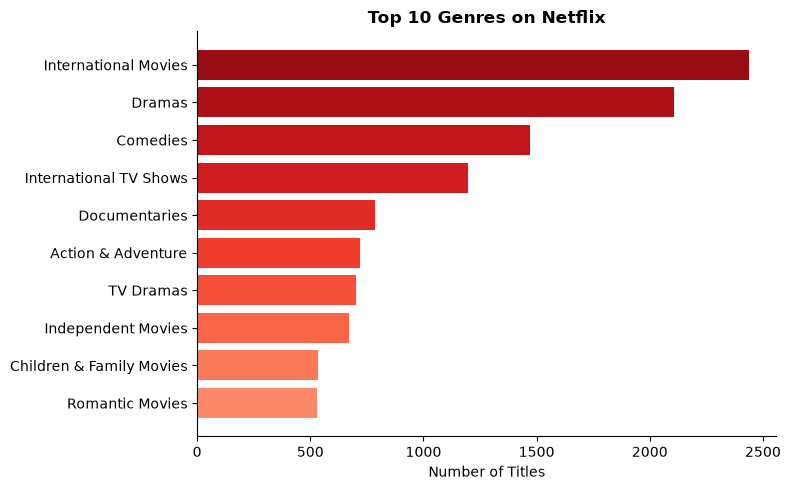

In [13]:
import matplotlib.pyplot as plt

top_genres = df_genres['genres_list'].value_counts().head(10).sort_values()

fig, ax = plt.subplots(figsize=(8,5))
colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(top_genres)))
ax.barh(top_genres.index, top_genres.values, color=colors)
ax.set_xlabel('Number of Titles')
ax.set_title('Top 10 Genres on Netflix', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**Observation:** International Movies and Dramas dominate the catalog, together accounting for over 4,500 titles, more than half the top-10 genre total combined.

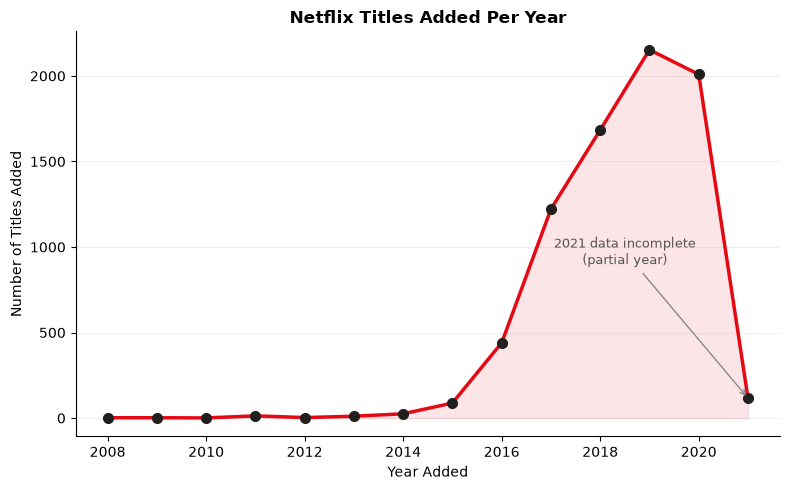

In [14]:
yearly = df['year_added'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(yearly.index, yearly.values, color='#E50914', linewidth=2.5, marker='o', markersize=7, markerfacecolor='#221f1f', markeredgecolor='#221f1f')
ax.fill_between(yearly.index, yearly.values, color='#E50914', alpha=0.1)
ax.annotate('2021 data incomplete\n(partial year)', xy=(2021, 117), xytext=(2018.5, 900), fontsize=9, color='#555', ha='center', arrowprops=dict(arrowstyle='->', color='#888'))
ax.set_xlabel('Year Added')
ax.set_ylabel('Number of Titles Added')
ax.set_title('Netflix Titles Added Per Year', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

This shows us that title additions grew sharply between 2016 and 2019, before leveling off in 2020.

The apparent drop in 2021 reflects incomplete data for that year, not an actual decline.

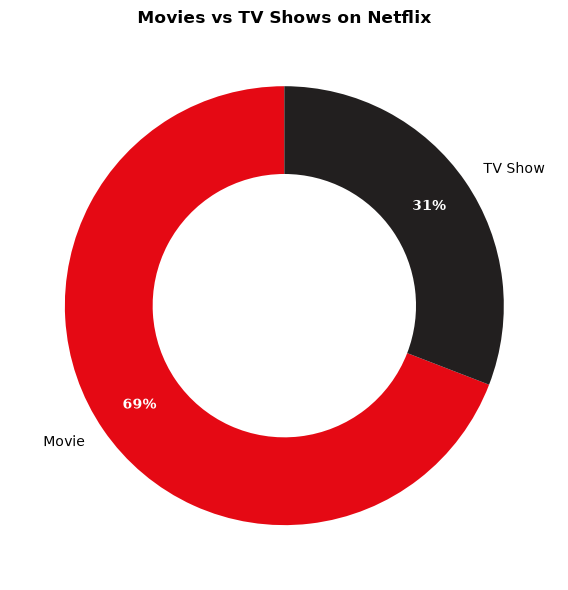

In [15]:
type_counts = df['type'].value_counts()

fig, ax = plt.subplots(figsize=(6,6))
wedges, texts, autotexts = ax.pie(type_counts.values, labels=type_counts.index, colors=['#E50914', '#221f1f'], autopct='%1.0f%%', pctdistance=0.8, startangle=90, wedgeprops=dict(width=0.4))
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax.set_title('Movies vs TV Shows on Netflix', fontweight='bold')
plt.tight_layout()
plt.show()

The 69/31 split visually reinforces that Movies remain the dominant format, even as the underlying genre mix shifts over time.

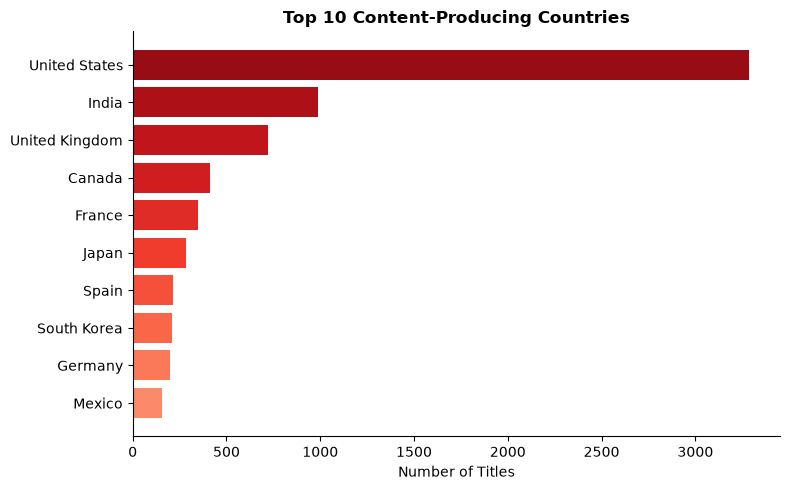

In [16]:
top_countries = df_countries[df_countries['country_list'] != 'Unknown']['country_list'].value_counts().head(10).sort_values()

fig, ax = plt.subplots(figsize=(8,5))
colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(top_countries)))
ax.barh(top_countries.index, top_countries.values, color=colors)
ax.set_xlabel('Number of Titles')
ax.set_title('Top 10 Content-Producing Countries', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

The United States dominates content production by a wide margin, but India's clear second-place position signals early international content investment.

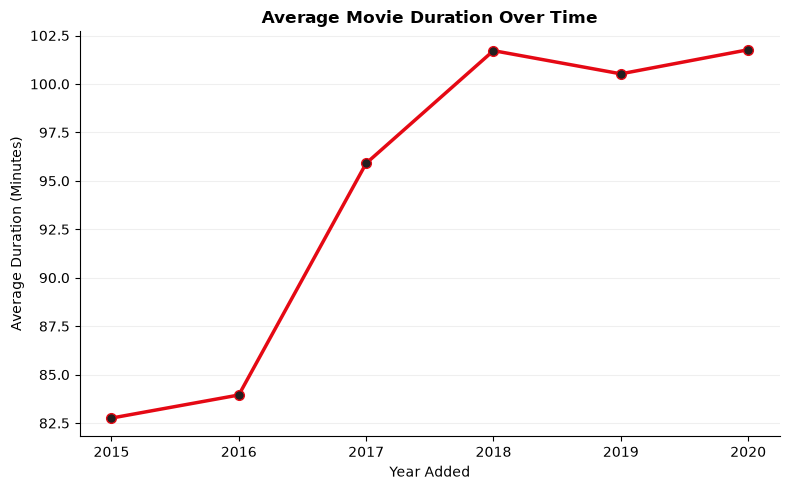

In [17]:
movie_duration_trend = df[df['type']=='Movie'].groupby('year_added')['duration_minutes'].mean()
movie_duration_trend = movie_duration_trend[(movie_duration_trend.index >= 2015) & (movie_duration_trend.index <= 2020)]

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(movie_duration_trend.index, movie_duration_trend.values, color='#E50914', linewidth=2.5, marker='o', markersize=7, markerfacecolor='#221f1f')
ax.set_xlabel('Year Added')
ax.set_ylabel('Average Duration (Minutes)')
ax.set_title('Average Movie Duration Over Time', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()


Average movie lenght increased from about 83 minutes (2015) to roughly 100 minutes (2018 onward), suggesting a shift toward longer-format films in recent additions.

## Step 10. Genre Trends Over Time - Identifying Growth Areas
- Compare each top-10 genre's title count between an early period (2016-2017) and a recent period (2019-2020), using `year_added` - the years before 2016 are too sparse to be reliable and 2021 is excluded as it's a partial year
- Calculate percentage growth per genre between these two periods
- Visualize the trend over time for the fastes-growing genres and rank all genres by growth rate

In [18]:
df_genres = df.explode('genres_list').reset_index(drop=True)
df_genres['genres_list'] = df_genres['genres_list'].str.strip()

In [19]:
top10 = df_genres['genres_list'].value_counts().head(10).index

early = df_genres[(df_genres['year_added'].isin([2016, 2017])) & (df_genres['genres_list'].isin(top10))]
recent = df_genres[(df_genres['year_added'].isin([2019, 2020])) & (df_genres['genres_list'].isin(top10))]

early_counts = early['genres_list'].value_counts()
recent_counts = recent['genres_list'].value_counts()

growth = pd.DataFrame({'early_2016_17': early_counts, 'recent_2019_20': recent_counts}).fillna(0)
growth['pct_growth'] = ((growth['recent_2019_20'] - growth['early_2016_17']) / growth['early_2016_17']) * 100
growth = growth.sort_values('pct_growth', ascending=False)
growth



,early_2016_17,recent_2019_20,pct_growth
genres_list,,,
Romantic Movies,75,336,348.000000
Comedies,240,876,265.000000
Children & Family Movies,97,319,228.865979
Action & Adventure,126,398,215.873016
Dramas,363,1143,214.876033
International Movies,503,1219,142.345924
Independent Movies,148,350,136.486486
International TV Shows,297,666,124.242424
TV Dramas,177,387,118.644068


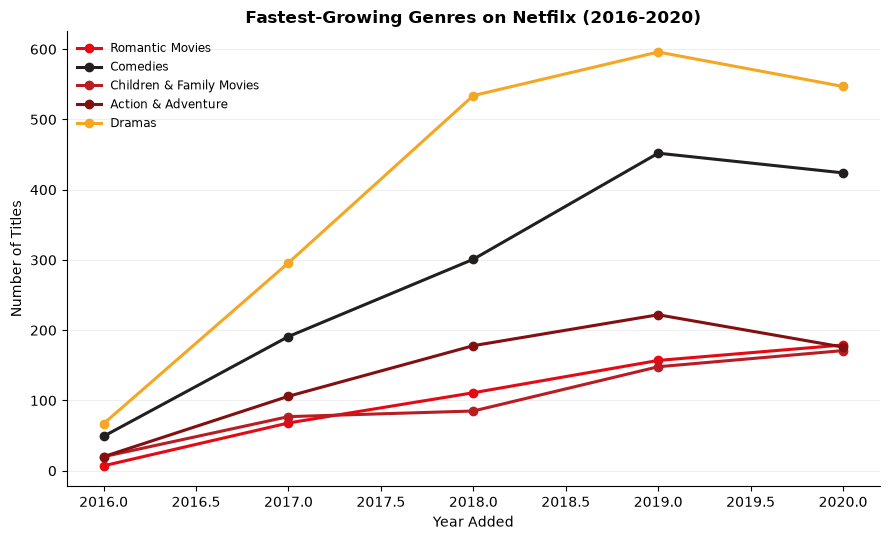

In [20]:
top5_growth_genres = growth.head(5).index
trend_data = df_genres[(df_genres['genres_list'].isin(top5_growth_genres)) & (df_genres['year_added'].between(2016, 2020))]
pivot = trend_data.groupby(['year_added', 'genres_list']).size().unstack()

fig, ax = plt.subplots(figsize=(9, 5.5))
palette = ['#E50914', '#221f1f', '#B81D24', '#831010', '#f5a623']
for i, genre in enumerate(top5_growth_genres):
    ax.plot(pivot.index, pivot[genre], marker='o', linewidth=2.2, label=genre, color=palette[i])
ax.set_xlabel('Year Added')
ax.set_ylabel('Number of Titles')
ax.set_title('Fastest-Growing Genres on Netfilx (2016-2020)', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper left', fontsize=8.5, frameon=False)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

Dramas lead in absolute growth, but Romantic Movies and Comedies show the steepest upward trajectories relative to their starting point.

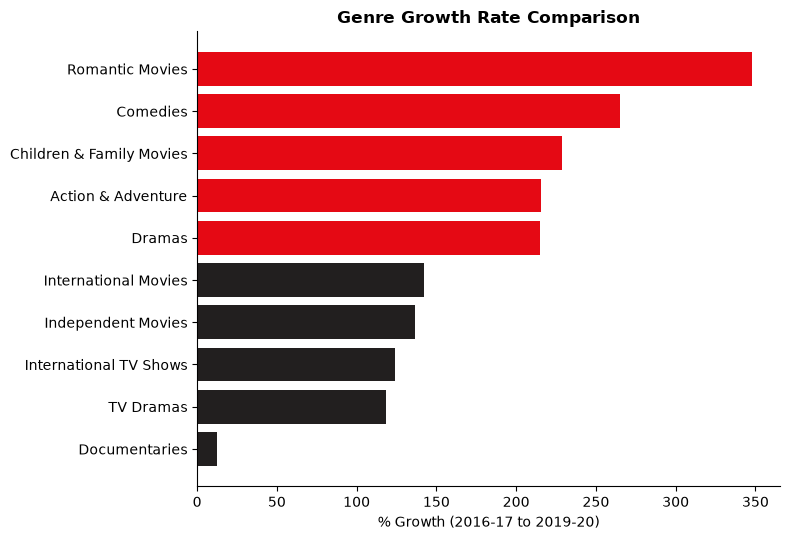

In [21]:
fig, ax = plt.subplots(figsize=(8, 5.5))
colors = ['#E50914' if x >=200 else '#221f1f' for x in growth['pct_growth']]
ax.barh(growth.index[::-1], growth['pct_growth'][::-1], color=colors[::-1])
ax.set_xlabel('% Growth (2016-17 to 2019-20)')
ax.set_title('Genre Growth Rate Comparison', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

Romantic Movies grew 348% between the two periods compared, far outpacing Documentaries at just 12%, despite Documentaries being a well-established genre.

## Step 11. Hypothesis Testing

### Hypothesis Testing 1
**Research Question:** Has the genre mix of Netflix content changed significantly between an early period (2016-2017) and a recent period (2019-2020)?

- **H0:** Genre distribution is independent of time period (no meaningful shift)
- **Ha:** Genre distribution is dependent on time period (a meaningful shift has occurred)

Since both variables are categorical (genre, period), a **chi-square test of independence** is used. Expected cell frequencies are checked first to confirm the test's assumptions hold.

In [22]:
from scipy.stats import chi2_contingency

top10 = df_genres['genres_list'].value_counts().head(10).index
subset = df_genres[(df_genres['genres_list'].isin(top10)) & (df_genres['year_added'].isin([2016, 2017, 2019, 2020]))].copy().reset_index(drop=True)
subset['period'] = np.where(subset['year_added'].isin([2016, 2017]), 'Early (2016-17)', 'Recent (2019-20)')

contingency = pd.crosstab(subset['genres_list'], subset['period'])
contingency

period,Early (2016-17),Recent (2019-20)
genres_list,,
Action & Adventure,126,398
Children & Family Movies,97,319
Comedies,240,876
Documentaries,275,309
Dramas,363,1143
Independent Movies,148,350
International Movies,503,1219
International TV Shows,297,666
Romantic Movies,75,336


### Genre x Time Period Heatmap
Visualizing the contingency table used in the chi-square test below.

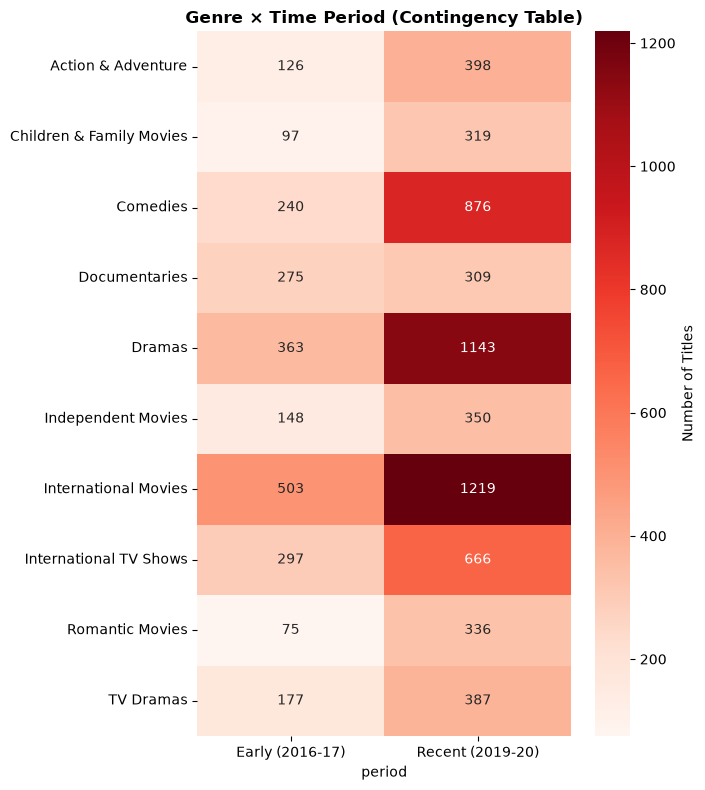

In [23]:
import seaborn as sns

heatmap_data = contingency.copy()
fig, ax = plt.subplots(figsize=(7,8))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='Reds', cbar_kws={'label': 'Number of Titles'}, ax=ax)
ax.set_title('Genre \u00d7 Time Period (Contingency Table)', fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

**Observation:** Recent-period counts are consistently higher across all genres, reflecting Netflix's overall catalog growth - the chi-square test below checks whether the *relative* distribution across genres changed, not just the raw totals.

In [24]:
chi2, p, dof, expected = chi2_contingency(contingency)

expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)
min_expected = expected.min()

print(f"Chi-square statistics: {chi2:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p:.6f}")
print(f"Minimum expected frequency: {min_expected:.2f} (assumption holds if >= 5)")

Chi-square statistics: 178.052
Degrees of freedom: 9
p-value: 0.000000
Minimum expected frequency: 113.89 (assumption holds if >= 5)


In [25]:
n = contingency.sum().sum()
min_dim = min(contingency.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))

print(f"Cramer's V: {cramers_v:.3f}")

Cramer's V: 0.146


**Result:** A chi-square test of independence showed a statistically association between genre and time period, χ²(9, N=7,627) = 178.05, p<.001, Cramer's V = .146.

We reject H0: the genre mix has significantly changed between 2016-17 and 2019-20. However, the effect size indicates the shift, while statistically real, is modest in magnitude since genres like Romantic Movies and Comedies have grown disproportionately, but the overall catalog composition has not been transformed wholesale.

**Observation:** The result is statistically significant, but the modest effect size (Cramer's V = 0.146) indicates a real but not dramatic shift in genre composition.

### Hypothesis Testing 2: Content Format Shift (Movie vs TV Show)

**Research Question:** Has Netflix's content mix shifted toward TV Shows (retention-driving) over Movies (acquisition-driving) between the early and recent periods?

- **H0:** Content type is independent of time period
- **Ha:** Content type is dependent on time period

Tested with a chi-square test of independence, same method as Hypothesis 1, since this is also two categorical variables.

In [26]:
subset_type = df[df['year_added'].isin([2016, 2017, 2019, 2020])].copy()
subset_type['period'] = np.where(subset_type['year_added'].isin([2016, 2017]), 'Early (2016-17)', 'Recent (2019-20)')

contingency2 = pd.crosstab(subset_type['type'], subset_type['period'])
contingency2

period,Early (2016-17),Recent (2019-20)
type,,
Movie,1117,2809
TV Show,545,1353


In [27]:
chi2_2, p_2, dof_2, expected_2 = chi2_contingency(contingency2)

print(f"Chi-square statistics: {chi2_2:.3f}")
print(f"Degrees of freedom: {dof_2}")
print(f"p-value: {p_2:.6f}")
print(f"Minimum expected frequency: {expected_2.min():.2f} (assumption holds if >= 5)")

Chi-square statistics: 0.031
Degrees of freedom: 1
p-value: 0.859170
Minimum expected frequency: 541.63 (assumption holds if >= 5)


In [28]:
n2 = contingency2.sum().sum()
cramers_v_2 = np.sqrt(chi2_2 / n2)

print(f"Cramer's V: {cramers_v_2:.3f}")

Cramer's V: 0.002


**Result:** A chi-square test of independence found no significant association between content type and time period, χ²(1, N=5,824) = 0.031, p = .859, Cramer's V = .002.

We fail to reject H0: Netflix's Movie/TV Show split has remained stable (32.8% TV Shows in 2016-17 vs 32.5% in 2019-20). 
This indicates the genre groeth identified in Hypothesis 1 is occurring proportionally within both formats, rather than reflecting a deliberate pivot toward one format over the other.

**Observation:** Unlike Hypothesis 1, this result is notsignificant - the Movie/TV Show split barely moved (32.8% \u2192 32.5% TV Shows), indicating genre growth is not a format strategy.

## Step 12. Data Quality Assessment

Since the problem statement raises the question of how reliable these conclusions are given metadata gaps, this section checks whether missingness is randomly distributed or concentrated in a way that could bias the findings.

- Compare `country` missingness rate between the early and recent periods (checks for bias in the core growth conclusion)
- Compare `country` missingness rate across genres (checks for bias in any genre_specific claims)

In [29]:
raw_check = pd.read_csv('netflix_titles.csv')
raw_check = raw_check.dropna(subset=['date_added', 'rating'])
raw_check.reset_index(drop=True, inplace=True)
raw_check['date_added'] = pd.to_datetime(raw_check['date_added'].str.strip())
raw_check['year_added'] = raw_check['date_added'].dt.year
raw_check['country_missing'] = raw_check['country'].isna()

period_check = raw_check[raw_check['year_added'].isin([2016, 2017, 2019, 2020])].copy()
period_check['period'] = np.where(period_check['year_added'].isin([2016, 2017]), 'Early (2016-17)', 'Recent (2019-20)')

period_check.groupby('period')['country_missing'].mean() * 100

period
Early (2016-17)     5.054152
Recent (2019-20)    6.703508
Name: country_missing, dtype: float64

In [30]:
raw_check['genres_list'] = raw_check['listed_in'].str.split(', ')
exploded_check = raw_check.explode('genres_list')
exploded_check['genres_list'] = exploded_check['genres_list'].str.strip()

genre_missing = exploded_check[exploded_check['genres_list'].isin(top10)].groupby('genres_list')['country_missing'].mean() * 100
genre_missing.sort_values(ascending=False)

genres_list
International TV Shows      13.032581
TV Dramas                   11.522048
Children & Family Movies     9.962406
Documentaries                5.597964
International Movies         3.898236
Comedies                     2.855201
Dramas                       2.090261
Action & Adventure           2.080444
Romantic Movies              1.883239
Independent Movies           0.445765
Name: country_missing, dtype: float64

**Observation:** Missing country data is concentrated in International TV Shows (13.0%), TV Dramas (11.5%) and Children & Family Movies (10.0%) - far higher than Independent Movies (0.4%)

**Conclusion:** `country` missingness s similar across the two time periods compared (5.1% vs 6.7%), indicating the core genre-growth finding is not meaningfully biased by this gap. 

However, missingness is unevenly distributed across genres 
        - International TV Shows (13.0%)
        - TV Dramas (11.5%)
        - Children & Family Movies (10.0%)
have notably higher missing country data than genres like Independent Movies (0.4%). Any future country-level extension of this analysis should treat these genres' regional figures with caution.

## Step 13. Key Findings Summary

**Problem Statement Recap:** How has Netflix's content genre mix evolved over time and which genres represent Netflix's most active growth areas and how how reliable are these conclusions given gaps in the underlying content metadata?

**Finding 1 - Genre mix has shifted significantly.** A chi-square test of independence confirmed genre distribution differs significantly between 2016-17 and 2019-20 (χ²(9, N=7,627) = 178.05, p <0.001), though the effect size (Cramer's V = 0.146) indicates the shift is rel but modest - not a wholesale transformation of the catalog.

**Finding 2 - Romantic Movies, Comedies and Children & Family Movies are Netflix's fastest-growing genres**, each growing over 200% between the two periods, while Documentaries grew just 12% despite being a well-established genre. These three genres represent Netflix's most active content investment areas.

**Finding 3 - This growth is not driven by a format shift.** A second chi-square test found no significant association between content type (Movie vs TV Show) and time period (χ²(1, N=5,824) = 0.03, p = 0.859) - the Movie/TV Show split stayed almost identical (32.8% vs 32.5% TV Shows). Genre growth is happening proportionally within both formats, not because Netflix pivoted toward one format.

**Finding 4 - Conclusions are reliable at the genre-growth level, but not uniformly at the country level.** Missing `country` data is similarly low across both periods (5.1% vs 6.7%), so the core growth finding isn't meaningfully biased. However, missingness is concentrated in specific genres - International TV Shows (13.0%), TV Dramas (11.5%) and Children & Family Movies (10.0%) meaning any future country-specific breakdown of these particular genres should be treated with caution.

**Recommendation:** If prioritizing future content investment, Romantic Movies, Comedies and Children & Family content represent Netflix's demonstrated growth areas, while Documentaries have remained comparatively flat. This pattern holds across both Movie and TV Show formats, suggesting genre - not format - is the more meaningful lens for investment decisions.

## Step 14. Limitations & References

**Limitations:**
- **Partial final year:** 2021 data reflects only a partial year (117 titles vs 2,009 in 2020) since the dataset was captured mid-year - excluded from growth period comparisons to avoid distortion.
- **Sparse early years:** 2008-2015 combined account for fewer than 150 titles, reflecting Netflix's early streamong catalog rather than a meaningful trend - excluded from the growth analysis for the same reason.
- **Snapshot in time:** the dataset reflects titles available as of its collection date; it does not capture titles removed from the platform, so catalog turnover isn't accounted for.
- **Metadata gaps:** as shown in Step 12, `director` (30.7%), `cast` (9.2%) and `country` (6.5%) contain missing values. These were retained (filled as "Unknown") rather than dropped, since they are not central to the genre-growth question, but any analysis extending into director/cast/country-specific claims - particularly for International TV Shows, TV Dramas, or Children & Family Movies - should account for this gap.
- **Single-platform scope:** findings describe Netflix's own catalog only and are not compared against competing streaming platforms, so conclusions about "growth" are relative to Netflix's own history, not the broader industry.

**References:**
- Netflix Movies and TV Shows Dataset, originally compiled by Shivam Bansal, distributed via the TidyTuesday project (2021-04-20), R for Data Science.
- McHugh, M. L. (2013). The Chi-square test of independence. *Biochemia Medica*, 23(2), 143-149.
- Netflix, Inc. (2020). *Notice of 2020 Annual Meeting of Stockholders and Proxy Statement* (Form DEF 14A). U.S. Securities and Exchange Commission.

